
# Lab_3: PDE with FDM

## SEBASTIAN ELADIO MENA TORRES

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Solve the Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explaint in words the strategy.
3. Compare with the Fourier serie. How many terms in the fourier serie are necessary to obtain a $\text{tol}=10^{-3}$?

FDM convergió en 2151 iteraciones para una tolerancia de 0.001


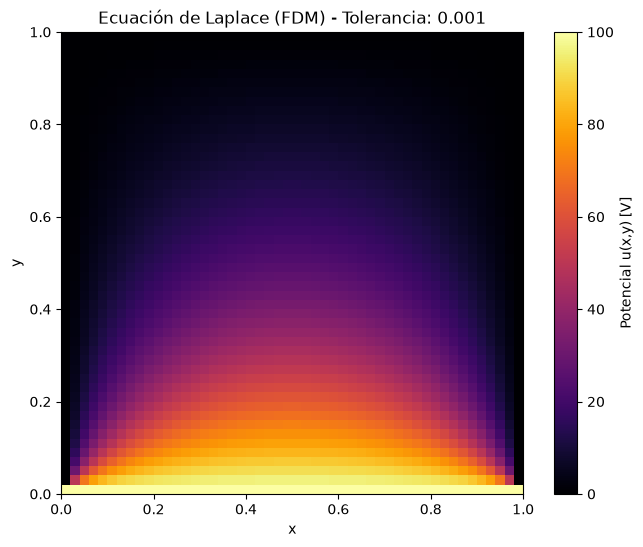

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PARTE 1: Método de Jacobi (FDM)
# ==========================================
def solve_laplace_fdm(L, N, V0, tol):
    """
    Resuelve la ecuación de Laplace usando el método de Jacobi (vectorizado).
    L: Longitud del dominio
    N: Número de puntos en la cuadrícula
    V0: Potencial en el borde inferior (y=0)
    tol: Tolerancia para la convergencia
    """
    # Inicializar la cuadrícula con ceros
    u = np.zeros((N, N))
    
    # Condiciones de frontera de Dirichlet
    # u(x, L) = 0 (Fila superior, índice -1)
    # u(0, y) = 0 (Columna izquierda, índice 0)
    # u(L, y) = 0 (Columna derecha, índice -1)
    # u(x, 0) = V0 (Fila inferior, índice 0 - usaremos origin='lower' al graficar)
    u[0, :] = V0 
    
    error = 1.0
    iteraciones = 0
    
    while error > tol:
        u_old = u.copy()
        
        # Aplicar FDM vectorizado (Promedio de los 4 vecinos para cada nodo interno)
        # u[y, x] = 0.25 * (u[y+1, x] + u[y-1, x] + u[y, x+1] + u[y, x-1])
        u[1:-1, 1:-1] = 0.25 * (u_old[2:, 1:-1] + u_old[:-2, 1:-1] + 
                                u_old[1:-1, 2:] + u_old[1:-1, :-2])
        
        # Calcular el error máximo en esta iteración
        error = np.max(np.abs(u - u_old))
        iteraciones += 1
        
    return u, iteraciones

# Parámetros iniciales
L = 1.0
N = 50 # Cuadrícula de 50x50
V0 = 100.0
tolerancia_fdm = 1e-3

# Ejecutar la simulación
u_fdm, iters = solve_laplace_fdm(L, N, V0, tolerancia_fdm)
print(f"FDM convergió en {iters} iteraciones para una tolerancia de {tolerancia_fdm}")

# Graficar el resultado de FDM
plt.figure(figsize=(8, 6))
plt.imshow(u_fdm, origin='lower', extent=[0, L, 0, L], cmap='inferno')
plt.colorbar(label='Potencial u(x,y) [V]')
plt.title(f'Ecuación de Laplace (FDM) - Tolerancia: {tolerancia_fdm}')
plt.xlabel('x')
plt.ylabel('y')
plt.show()




**La estrategia** consiste en discretizar el dominio en una cuadrícula de nodos donde se fijan las condiciones de frontera (100 V en la base y 0 V en el resto) y se inicializa el interior en 0 V. Apoyándose en la propiedad fundamental de la ecuación de Laplace discretizada, la cual establece que el potencial de un punto es exactamente el promedio de sus cuatro vecinos ortogonales, el método de Jacobi actualiza iterativamente el valor de cada nodo interno utilizando los datos de la iteración inmediatamente anterior. Este proceso propaga gradualmente el voltaje desde la base hacia el interior de la placa y se repite de forma continua hasta que la variación máxima de cualquier nodo entre dos iteraciones consecutivas caiga por debajo de la tolerancia exigida ($10^{-3}$), garantizando así que el sistema ha alcanzado el estado estacionario.

In [11]:
# ==========================================
# PARTE 2: Comparación con la Serie de Fourier
# ==========================================
def laplace_fourier_term(x, y, L, V0, n):
    """
    Calcula el n-ésimo término (impar) de la serie de Fourier. Ya se de antemano que los términos pares son cero debido a la simetría de la condición de frontera.
    """
    # Evitar overflow matemático reescribiendo los senos hiperbólicos para n grandes
    coef = (4 * V0) / (n * np.pi)
    termino_y = np.sinh(n * np.pi * (L - y) / L) / np.sinh(n * np.pi)
    termino_x = np.sin(n * np.pi * x / L)
    
    return coef * termino_x * termino_y

def find_fourier_terms(L, N, V0, tol):
    """
    Encuentra cuántos términos de la serie son necesarios para una tolerancia dada.
    """
    x = np.linspace(0, L, N)
    y = np.linspace(0, L, N)
    X, Y = np.meshgrid(x, y)
    
    u_fourier = np.zeros((N, N))
    n = 1  # Iniciar en el primer término impar
    term_count = 0
    max_change = 1.0
    
    while max_change > tol:
        term = laplace_fourier_term(X, Y, L, V0, n)
        
        # Medir el cambio máximo omitiendo la frontera y=0
        max_change = np.max(np.abs(term[1:, :])) 
        
        u_fourier += term
        term_count += 1
            
        n += 2  # Saltar directamente al siguiente término impar (1, 3, 5...)
        
        if term_count > 500: 
            break
            
    return u_fourier, term_count

tolerancia_fourier = 1e-4
u_fourier, num_terminos = find_fourier_terms(L, N, V0, tolerancia_fourier)
print(f"La serie de Fourier requirió {num_terminos} términos (impares) para una tolerancia de {tolerancia_fourier}")

La serie de Fourier requirió 25 términos (impares) para una tolerancia de 0.0001



#### **Exercise 2**: FDM for oppen boundaries (optional)

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="300" height="400" />

Convergencia alcanzada en 4112 iteraciones.


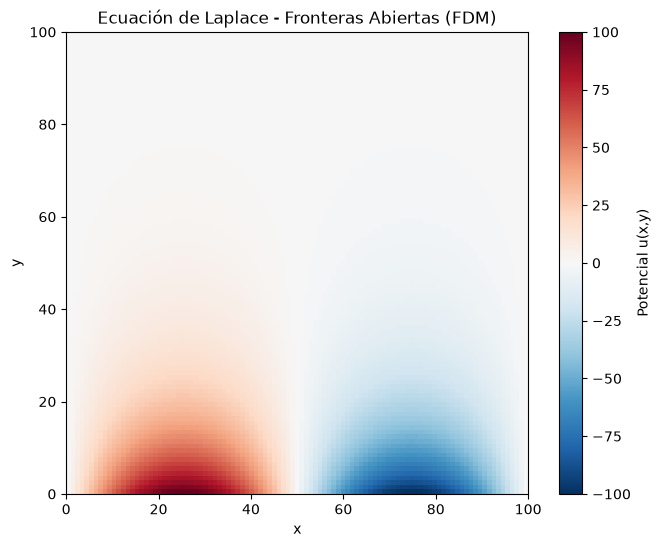

In [12]:

# Parámetros del modelo numérico
L = 100
Delta = 1
N = int(L / Delta) + 1  # 101 puntos para incluir el 0 y el 100
u0 = 100
tol = 1e-4

# Crear la cuadrícula espacial (truncando el infinito en y = L)
x = np.linspace(0, L, N)
u = np.zeros((N, N))

# Condición de frontera en y=0 (borde inferior)
u[0, :] = u0 * np.sin(2 * np.pi * x / L)

# Los bordes izquierdo (x=0), derecho (x=L) y superior (y->inf) ya son 0
# gracias a la inicialización con np.zeros

error = 1.0
iteraciones = 0

# Iteración de Jacobi con slicing
while error > tol:
    u_old = u.copy()
    
    # Calcular promedios para nodos internos
    u[1:-1, 1:-1] = 0.25 * (u_old[2:, 1:-1] + u_old[:-2, 1:-1] + 
                            u_old[1:-1, 2:] + u_old[1:-1, :-2])
    
    error = np.max(np.abs(u - u_old))
    iteraciones += 1

print(f"Convergencia alcanzada en {iteraciones} iteraciones.")

# Visualización
plt.figure(figsize=(8, 6))
# Se usa origin='lower' para que el índice 0 de la matriz corresponda a y=0
plt.imshow(u, origin='lower', extent=[0, L, 0, L], cmap='RdBu_r')
plt.colorbar(label='Potencial u(x,y)')
plt.title('Ecuación de Laplace - Fronteras Abiertas (FDM)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### Solución Analítica: Ecuación de Laplace con Fronteras Abiertas

Partimos de la ecuación de Laplace en dos dimensiones:

$$\nabla^2 u = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0$$

Sujeta a las siguientes condiciones de frontera de Dirichlet:
1. $u(0, y) = 0$ (Borde izquierdo)
2. $u(L, y) = 0$ (Borde derecho)
3. $u(x, \infty) = 0$ (Borde superior en el infinito)
4. $u(x, 0) = u_0 \sin\left(\frac{2\pi x}{L}\right)$ (Borde inferior)

**1. Separación de variables:**
Proponemos una solución del tipo $u(x,y) = X(x)Y(y)$. Reemplazando en la ecuación diferencial y dividiendo por $X(x)Y(y)$:

$$\frac{X''(x)}{X(x)} = -\frac{Y''(y)}{Y(y)} = -k^2$$

Donde $-k^2$ es la constante de separación (negativa para obtener soluciones oscilatorias en $x$).

**2. Solución para X(x):**
La ecuación ordinaria es $X''(x) + k^2X(x) = 0$, cuya solución general es:

$$X(x) = A \cos(kx) + B \sin(kx)$$

Aplicando las condiciones de frontera laterales:
* $X(0) = 0 \implies A = 0$
* $X(L) = 0 \implies B \sin(kL) = 0$

Para que exista una solución no trivial ($B \neq 0$), se debe cumplir que $kL = n\pi$, lo que cuantiza la constante $k$:

$$k_n = \frac{n\pi}{L}, \quad \text{para } n = 1, 2, 3, \dots$$

**3. Solución para Y(y):**
La ecuación ordinaria es $Y''(y) - k^2Y(y) = 0$, cuya solución general es:

$$Y(y) = C e^{ky} + D e^{-ky}$$

Aplicando la condición en el infinito ($y \to \infty$):
* $Y(\infty) = 0 \implies C = 0$ (evita el crecimiento exponencial infinito).

Por lo tanto, la solución para $Y$ queda en términos de decaimiento exponencial:

$$Y_n(y) = D e^{-\frac{n\pi y}{L}}$$

**4. Solución general y aplicación de la base:**
Por el principio de superposición, la solución general es la suma de todas las soluciones posibles:

$$u(x,y) = \sum_{n=1}^{\infty} A_n \sin\left(\frac{n\pi x}{L}\right) e^{-\frac{n\pi y}{L}}$$

Evaluamos la condición de frontera en la base $y=0$:

$$u(x,0) = \sum_{n=1}^{\infty} A_n \sin\left(\frac{n\pi x}{L}\right) = u_0 \sin\left(\frac{2\pi x}{L}\right)$$

**5. Resultado final:**
Por comparación directa (ortogonalidad de las funciones seno), es evidente que el único término que sobrevive en la serie es aquel donde $n = 2$. Esto nos da la constante $A_2 = u_0$, mientras que para todo $n \neq 2$, $A_n = 0$.

Sustituyendo $n=2$ y $A_2=u_0$ en la solución general, obtenemos la solución analítica exacta:

$$u(x,y) = u_0 \sin\left(\frac{2\pi x}{L}\right) e^{-\frac{2\pi y}{L}}$$

---


#### **Exercise 3**: Electric filed and potential in a parallel-plate capacitor

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically the electric field (use finite difference method).

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>

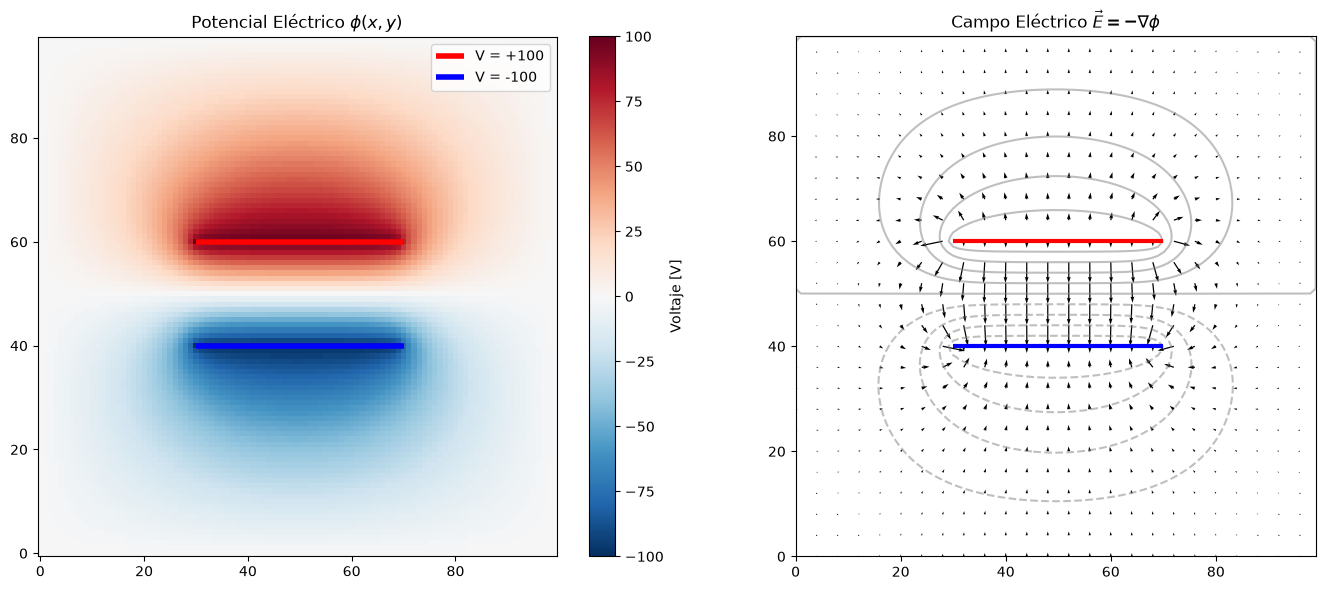

In [13]:
# Parámetros del espacio y tolerancia
N = 100
tol = 1e-4
error = 1.0

# Inicializar la matriz de potencial
phi = np.zeros((N, N))

# Coordenadas y geometría de las placas
x_inicio, x_fin = 30, 70  # Ancho de las placas
y_placa_sup = 60
y_placa_inf = 40
voltaje = 100.0

# Función para aplicar/restaurar las condiciones de las placas
def aplicar_condiciones_placas(matriz):
    matriz[y_placa_sup, x_inicio:x_fin] = voltaje   # Placa positiva
    matriz[y_placa_inf, x_inicio:x_fin] = -voltaje  # Placa negativa
    return matriz

# Aplicar las placas por primera vez
phi = aplicar_condiciones_placas(phi)

# Iteración FDM (Jacobi)
while error > tol:
    phi_old = phi.copy()
    
    # Ecuación de Laplace para nodos internos
    phi[1:-1, 1:-1] = 0.25 * (phi_old[2:, 1:-1] + phi_old[:-2, 1:-1] + 
                              phi_old[1:-1, 2:] + phi_old[1:-1, :-2])
    
    # Re-aplicar el voltaje fijo de las placas (ya que la línea anterior las promedia)
    phi = aplicar_condiciones_placas(phi)
    
    # Calcular el error omitiendo las placas para medir solo el espacio libre
    error = np.max(np.abs(phi - phi_old))

# Calcular el campo eléctrico E = -∇phi usando el gradiente numérico (diferencias finitas)
# np.gradient devuelve (derivada_en_y, derivada_en_x)
Ey, Ex = np.gradient(-phi)

# ----------------- Visualización -----------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Potencial Eléctrico
img = ax1.imshow(phi, origin='lower', cmap='RdBu_r')
ax1.set_title(r'Potencial Eléctrico $\phi(x,y)$')
fig.colorbar(img, ax=ax1, label='Voltaje [V]')

# Dibujar rectángulos para señalar la posición de las placas
ax1.hlines(y_placa_sup, x_inicio, x_fin, color='red', linewidth=4, label='V = +100')
ax1.hlines(y_placa_inf, x_inicio, x_fin, color='blue', linewidth=4, label='V = -100')
ax1.legend(loc='upper right')

# Gráfico 2: Campo Eléctrico
# Seleccionar un subconjunto de puntos para no saturar el gráfico de flechas
salto = 4
X, Y = np.meshgrid(np.arange(N), np.arange(N))
ax2.quiver(X[::salto, ::salto], Y[::salto, ::salto], 
           Ex[::salto, ::salto], Ey[::salto, ::salto], 
           color='black', scale=250)
ax2.contour(phi, levels=10, colors='gray', alpha=0.5) # Líneas equipotenciales
ax2.hlines(y_placa_sup, x_inicio, x_fin, color='red', linewidth=3)
ax2.hlines(y_placa_inf, x_inicio, x_fin, color='blue', linewidth=3)
ax2.set_title(r'Campo Eléctrico $\vec{E} = -\nabla\phi$')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()